In [1]:
import pandas as pd
df = pd.read_csv("raw_data.csv")


In [2]:
df["gender"].str.upper()
df["gender"].str.lower()
df["gender"].str.capitalize()
df["country"].str.contains("india", case=False)


0     False
1     False
2     False
3     False
4     False
5     False
6      True
7       NaN
8     False
9     False
10    False
Name: country, dtype: object

In [3]:
df2 = pd.read_csv("raw_data.csv")
df2
# apply()
df2["Tax"] = df2["income"] .apply(lambda x: "20%" if x > 60000 else "10%")

# map() 
df2["gender"] = df2["gender"].fillna("Unknown")
gen_map = {"Male": "M" , "Female" : "F" , "Unknown" : "U","NaN":"U1"}
df2["gender"] = df2["gender"].map(gen_map)
df2
# assign()
df2["new_income"] = df2["income"]*1.1
df2 = df2.assign(new_20 = df2["income"]*1.2)
df2["country"] = df2["country"].replace("USA", "US")
df2

,id,name,age,country,gender,income,Tax,new_income,new_20
0,1,John Doe,29.0,US,M,55000.0,10%,60500.0,66000.0
1,1,John Doe,29.0,US,M,55000.0,10%,60500.0,66000.0
2,2,Jane Smith,NaN,Canada,F,62000.0,20%,68200.0,74400.0
3,3,Alex,NaN,US,U,47000.0,10%,51700.0,56400.0
4,4,Maria Garcia,34.0,Spain,F,NaN,10%,NaN,NaN
5,5,Li Wei,27.0,China,M,51000.0,10%,56100.0,61200.0
6,6,NaN,45.0,India,F,73000.0,20%,80300.0,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,74800.0,81600.0
8,8,Rachel Lee,29.0,US,F,62000.0,20%,68200.0,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,49500.0,54000.0


In [4]:
col = [col for col in df2.columns if col !="id"]  + ["id"]
# # print(col)
df2=df2[col]

df2[["age","income","new_income","new_20"]] =df2[["age","income","new_income","new_20"]].fillna({
    "age": df2["age"].mode()[0],
    "income": df2["income"].mean(),
    "new_income": df2["new_income"].mean(),
    "new_20": df2["new_20"].mean() 
})
# df2["gender"] = df2["gender"].map({"NaN":"U"})
df2=df2.drop_duplicates()
df2=df2.dropna()
df2.to_csv("my.csv")

In [5]:
df2.groupby(["country" ,"gender"])["income"].mean().reset_index()

,country,gender,income
0,Canada,F,62000.0
1,China,M,51000.0
2,Mexico,M,45000.0
3,Spain,F,57600.0
4,US,F,62000.0
5,US,M,55000.0
6,US,U,52500.0


In [9]:
melted_df = df2.melt(
    id_vars = ["country", "id"],
    value_vars= ["name","age","gender","income","Tax","new_income","new_20"],
    var_name = "metrics",
    value_name = "value" )
# print(melted_df)


<Axes: xlabel='age', ylabel='income'>

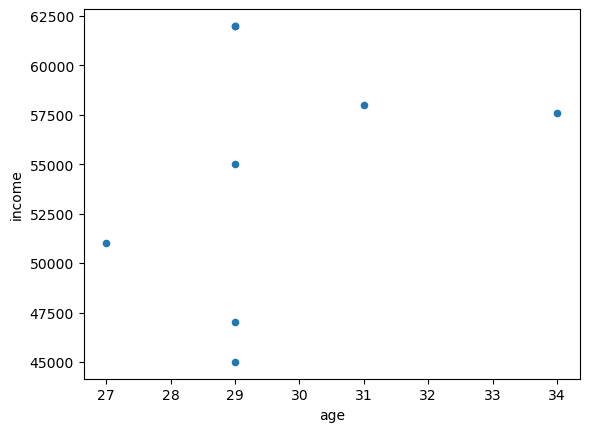

In [15]:
# df["age"].hist()
df2.plot(kind = "scatter", x="age", y="income")

In [31]:
df_customers = pd.DataFrame({
"customer_id": [1, 2, 3, 4],
"name": ["Adam", "Bob", "Charlie", "Dave"]
})
df_orders = pd.DataFrame({
"order_id": [101, 102, 103, 104],
"customer_id": [2, 1, 4, 5],
"amount": [250, 120, 300, 180]
})
pd.merge(df_customers,df_orders)
pd.merge(df_customers , df_orders , on="customer_id")  # inner join
pd.merge(df_customers , df_orders , on="customer_id" , how="left") #left join
pd.merge(df_customers , df_orders , on="customer_id" , how="right") #left right
pd.merge(df_customers , df_orders , on="customer_id" , how="outer") #left join
# pd.merge(df_customers , df_orders , on="customer_id" , how="left") #left join

,customer_id,name,order_id,amount
0,1,Adam,102.0,120.0
1,2,Bob,101.0,250.0
2,3,Charlie,NaN,NaN
3,4,Dave,103.0,300.0
4,5,NaN,104.0,180.0


In [38]:
pd.concat([df_customers,df_orders])
pd.concat([df_customers,df_orders])   .reset_index()
pd.concat([df_customers,df_orders],axis=1)

,customer_id,name,order_id,customer_id,amount
0,1,Adam,101,2,250
1,2,Bob,102,1,120
2,3,Charlie,103,4,300
3,4,Dave,104,5,180


In [32]:
df_customers


,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [23]:
df_orders

,order_id,customer_id,amount
0,101,2,250
1,102,1,120
2,103,4,300
3,104,5,180
